# Chroma dye pilot → AnnData

A comparison of alternative Cell Painting dyes ([`cpg0029`](https://broadinstitute.github.io/cellpainting-gallery/)). Each batch uses a different dye set, so feature sets are not shared across batches.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_negcon_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0029-chroma-pilot/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0029-chroma-pilot/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv.gz")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

6 batches, using 2023_05_15_Batch1


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name


AnnData object with n_obs × n_vars = 767 × 676
    obs: 'plate_map_name', 'control_type', 'broad_sample', 'mg_per_ml', 'mmoles_per_liter', 'solvent', 'BRD ID', 'BRD with batch', 'Common Name', 'MoA', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_Cytoplasm', 'Count_Nuclei', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "mmoles_per_liter", "MoA", "pert_type", "control_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_DNA,image,granularity,dna,NaN,1
Image_Granularity_11_AGP,image,granularity,agp,NaN,1
Image_Granularity_11_DNA,image,granularity,dna,NaN,1
Image_Granularity_12_AGP,image,granularity,agp,NaN,1
...,...,...,...,...,...
Nuclei_Texture_SumVariance_AGP_20_03_256,nuclei,texture,agp,NaN,1
Nuclei_Texture_SumVariance_Brightfield_20_01_256,nuclei,texture,brightfield,NaN,1
Nuclei_Texture_SumVariance_ER_20_00_256,nuclei,texture,er,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate", "mmoles_per_liter"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

767 wells x 675 features
non-finite: 0 | max|x|: 335200.0

Plate:
Plate
BR00122250    384
BR00122246    383

mmoles_per_liter:
mmoles_per_liter
 5.000    695
NaN        48
 0.027      8
 0.133      8
 0.333      8


In [6]:
adata.write_h5ad(PROFILES.parent / "chroma.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "mmoles_per_liter", "MoA"]))

,observed,baseline,ratio
covariate,,,
Plate,0.652,0.500,1.304
mmoles_per_liter,0.824,0.935,0.882
MoA,0.140,0.022,6.427


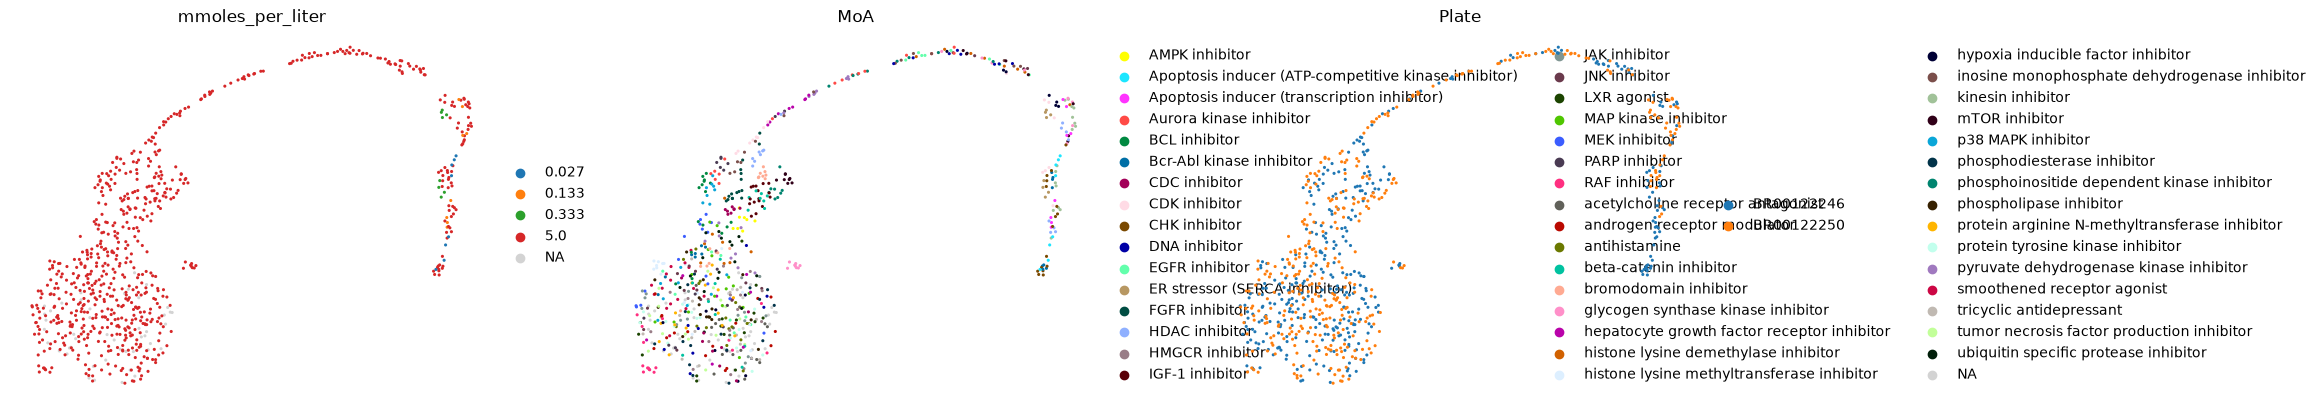

In [9]:
sc.pl.umap(
    adata, color=present(["mmoles_per_liter", "MoA", "Plate", "Count_Cells"])[:3], ncols=3, frameon=False, size=20
)